### Set Up

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import torch
import tensorflow as tf
import math
import re
import collections
from typing import Dict, List, Tuple
import os, pathlib, shutil, random
import string
import keras_hub
from functools import partial

In [3]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: Tesla T4


### Load Dataset

In [4]:
extract_dir = keras.utils.get_file(fname="mini-c4", origin=("https://hf.co/datasets/mattdangerw/mini-c4/resolve/main/mini-c4.zip"), extract=True, )
extract_dir = pathlib.Path(extract_dir) / "mini-c4"
extract_dir

PosixPath('/root/.keras/datasets/mini-c4/mini-c4')

In [5]:
with open(extract_dir / "shard0.txt", "r", encoding="utf-8") as f:
    print(f.readline().replace("\\n", "\n")[:100])

Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You


### Load Tokenizer

In [6]:
# Downloading a SentencePiece vocabulary and instantiating a tokenizer
vocabulary_file = keras.utils.get_file(origin="https://hf.co/mattdangerw/spiece/resolve/main/vocabulary.proto",)
tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(vocabulary_file)

In [7]:
tokenizer.tokenize("The quick brown fox.")

<tf.Tensor: shape=(6,), dtype=int32, numpy=array([  450,  4996, 17354,  1701, 29916, 29889], dtype=int32)>

In [8]:
tokenizer.detokenize([450, 4996, 17354, 1701, 29916, 29889])

'The quick brown fox.'

In [9]:
tokenizer.token_to_id("<|endoftext|>")

0

### Data Preprocess

In [10]:
#  Preprocessing text input for Transformer pretraining
batch_size = 32
sequence_length = 256
suffix = np.array([tokenizer.token_to_id("<|endoftext|>")])
def read_file(filename):
    ds = tf.data.TextLineDataset(filename)
    ds = ds.map(lambda x: tf.strings.regex_replace(x, r"\\n", "\n"))
    ds = ds.map(tokenizer, num_parallel_calls=8)
    return ds.map(lambda x: tf.concat([x, suffix], -1))

In [11]:
files = [str(file) for file in extract_dir.glob("*.txt")]
ds = tf.data.Dataset.from_tensor_slices(files)
ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)
ds = ds.rebatch(sequence_length + 1, drop_remainder=True)
ds = ds.map(lambda x: (x[:-1], x[1:]))
ds = ds.batch(batch_size).prefetch(8)

In [12]:
num_batches = 29373
num_val_batches = 500
num_train_batches = num_batches - num_val_batches

val_ds = ds.take(num_val_batches).repeat()
train_ds = ds.skip(num_val_batches).repeat()

### Model - A Transformer decoder only block without cross-attention

In [13]:
class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads):
        super().__init__()
        key_dim = hidden_dim // num_heads
        self.self_attention = keras.layers.MultiHeadAttention(
            num_heads, key_dim, dropout=0.1
        )
        self.self_attention_layernorm = keras.layers.LayerNormalization()
        self.feed_forward_1 = keras.layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = keras.layers.Dense(hidden_dim)
        self.feed_forward_layernorm = keras.layers.LayerNormalization()
        self.dropout = keras.layers.Dropout(0.1)

    def call(self, inputs):
        residual = x = inputs
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = self.dropout(x)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = self.dropout(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

### Positional Encoding

In [14]:
class PositionalEmbedding(keras.Layer):
  def __init__(self, sequence_length, input_dim, output_dim):
        super().__init__()
        self.token_embeddings = keras.layers.Embedding(input_dim, output_dim)
        self.position_embeddings = keras.layers.Embedding(sequence_length, output_dim)

  def call(self, inputs, reverse=False):
        if reverse:
            token_embeddings = self.token_embeddings.embeddings
            return keras.ops.matmul(inputs, keras.ops.transpose(token_embeddings))
        positions = keras.ops.cumsum(keras.ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

### Model

In [15]:
keras.config.set_dtype_policy("mixed_float16")
vocab_size = tokenizer.vocabulary_size()
hidden_dim = 256
intermediate_dim = 512
num_heads = 2
num_layers = 4

In [16]:
# Creating a mini-GPT functional model
inputs = keras.Input(shape=(None,), dtype="int32", name="inputs")
embedding = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)
x = embedding(inputs)
x = keras.layers.LayerNormalization()(x)
for i in range(num_layers):
    x = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(x)
outputs = embedding(x, reverse=True)
mini_gpt = keras.Model(inputs, outputs)
mini_gpt.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None,      │  8,257,536 │ inputs[0][0],     │
│ (PositionalEmbeddi… │ 32000)            │            │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 256) │        512 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 256) │    527,104 │ layer_normalizat… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │    527,104 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │    527,104 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │    527,104 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,366,464 (39.54 MB)

 Trainable params: 10,366,464 (39.54 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [17]:
# Defining a custom learning rate schedule
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self):
        self.rate = 2e-2
        self.warmup_steps = 10.0

    def __call__(self, step):
        step = keras.ops.cast(step, dtype="float32")
        scale = keras.ops.minimum(step / self.warmup_steps, 1.0)
        return self.rate * scale

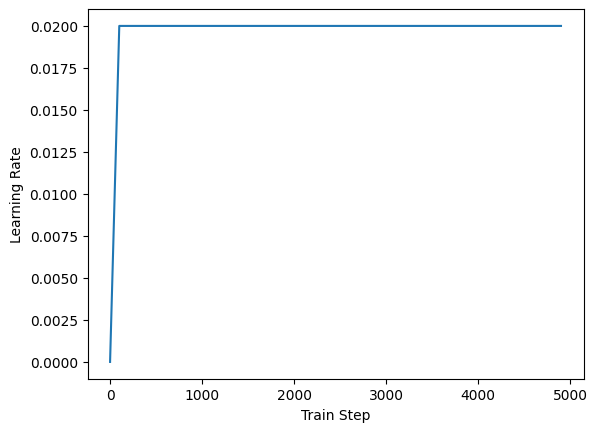

In [18]:
schedule = WarmupSchedule()
x = range(0, 5_000, 100)
y = [keras.ops.convert_to_numpy(schedule(step)) for step in x]
plt.plot(x, y)
plt.xlabel("Train Step")
plt.ylabel("Learning Rate")
plt.show()

In [19]:
mini_gpt.compile(optimizer=keras.optimizers.Adam(schedule),
                 loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])

In [20]:
num_epochs = 1
steps_per_epoch = num_train_batches // num_epochs
validation_steps = num_val_batches

mini_gpt.fit(train_ds, validation_data=val_ds, epochs=num_epochs, steps_per_epoch=steps_per_epoch,
             validation_steps=validation_steps)

28873/28873 ━━━━━━━━━━━━━━━━━━━━ 2073s 70ms/step - accuracy: 0.0302 - loss: nan - val_accuracy: 0.0185 - val_loss: 8.2787


### Inference

In [21]:
# A simple generation function for the mini-GPT model
def generate(prompt, max_length=64):
    tokens = list(keras.ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    for _ in range(max_length - prompt_length):
        prediction = mini_gpt(keras.ops.convert_to_numpy([tokens]))
        prediction = keras.ops.convert_to_numpy(prediction[0, -1])
        tokens.append(np.argmax(prediction).item())
    return tokenizer.detokenize(tokens)


In [22]:
# A compiled generation function for the mini-GPT model
def compiled_generate(prompt, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = mini_gpt.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        tokens[i] = np.argmax(prediction).item()
    return tokenizer.detokenize(tokens)

In [23]:
prompt = "A piece of advice"
generate(prompt)

'A piece of advice to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to'

In [24]:
prompt = "Hi"
generate(prompt)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


'Hi to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to'

### Sampling

In [25]:
prompt = "Hi"

In [26]:
def compiled_generate(prompt, sample_fn, max_length=64):
    tokens = list(keras.ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = mini_gpt.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        next_token = keras.ops.convert_to_numpy(sample_fn(prediction))
        tokens[i] = np.array(next_token).item()
    return tokenizer.detokenize(tokens)

In [27]:
def greedy_search(preds):
    return keras.ops.argmax(preds)
compiled_generate(prompt, greedy_search)

'Hi to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to'

In [28]:
def random_sample(preds, temperature=1.0):
    preds = preds / temperature
    return keras.random.categorical(preds[None, :], num_samples=1)[0]
compiled_generate(prompt, random_sample)

'Hi skills business to a item the as right paid: to your for\n anir So over) areTheer time that another and to about problems so length at and very foril salt Zrier is each and the a and\n sites O You w for to setting appear to/ aom services1 off if relevant'

In [29]:
compiled_generate(prompt, partial(random_sample, temperature=0.1))

'Hi the the the the to to to to to the to a and to to to the to to to to and the the and to the to to the to to the and the to to to to the to to to a to the the to to a the the and to the and the the to and a to the'

In [30]:
compiled_generate(prompt, partial(random_sample, temperature=0.5))

'Hi the\n is a- a\n and to and the\n to a and the\n is to and and\n the) with to the is and and to to be\n- the a it and\nings and the to\n and will and a\n the the the to to I is the, of in\n all'

In [31]:
compiled_generate(prompt, partial(random_sample, temperature=0.9))

'Hi the A to is out- and feelTheists patients a\n toItels keep and and is talking be by F more the of example right are Inter not works but time informed a that inv familyno it with working hit\n problems a what-ith to for very to in you and that andv team difference'

In [32]:
compiled_generate(prompt, partial(random_sample, temperature=1.5))

'Hi as sens well and different dis and feelAnd Div listsics Over in brings not that hat Happy apparent positive and tools S website meeting our can first giving ifMy II deceyible tree card pick be iron, subents”el E recentlyetimeas theely fashionick foril missedid pro reliefym does'

In [33]:
compiled_generate(prompt, partial(random_sample, temperature=2.0))

'Hi friendly pagesletConfigMyminumacJ becamea Bron fourth like Theycan leading lead satisfyughagen travellive winningatic mere comesarringL jation working management and."ay be required dimensionsNekaoud tur bookP more It During good knewvol person sign completed sitesoc theory Kar Dec makeed choosing intro'

In [34]:
compiled_generate(prompt, partial(random_sample, temperature=3.0))

'Hiatures4 increaseos steaporrelated stay Buck Minister show than ing PersonPayifting twiceressskindions states consists pr saves Ab raising inspectcial Network keepingabilityży props Socialiker st jazz H consumeDes to grace bring Am터athon uniqu poem Groupasa opposite Public leavesRes0 List anti not on� that play'

In [35]:
def top_k(preds, k=5, temperature=1.0):
    preds = preds / temperature
    top_preds, top_indices = keras.ops.top_k(preds, k=k, sorted=False)
    choice = keras.random.categorical(top_preds[None, :], num_samples=1)[0]
    return keras.ops.take_along_axis(top_indices, choice, axis=-1)

In [36]:
compiled_generate(prompt, partial(top_k, k=1))

'Hi to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to'

In [37]:
compiled_generate(prompt, partial(top_k, k=3))

'Hi the to the to and and to the to to to the to to the to the and to to and the the to and the to to the to to and the the to and to and to and the and to the and to the and and to to to and to the and and and and the and to the'

In [38]:
compiled_generate(prompt, partial(top_k, k=5))

'Hi to to\n and the a and the to and and and and a and the the\n to to\n and\n a to\n and the a the\n to\n to to to and to to and to and the to the to\n the the and\n to and a to\n to a to a the and a'

In [39]:
compiled_generate(prompt, partial(top_k, k=10))

'Hi of for and the the and a and to the\n a a to a to to and and to\n the and and is to a to,\n for\n and\n the a the\n the the a to the with is with a\n to, and of a a a to to the a\n a the the'

In [40]:
compiled_generate(prompt, partial(top_k, k=20))

'Hi or- of\n1 the and a of the the and for with to on and a,, for a of and the and and to an the to on with of to to that of, the of the you- for an of for and a a you a an the to is a is with is\n-'